<p style="text-align: center">
<img src="../../assets/images/dtlogo.png" alt="Duckietown" width="50%">
</p>

In [2]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt

# Kalman filter

Le filtre de Kalman (KF) est l'un des algorithmes d'estimation d'état les plus utilisés en robotique. En pratique, nous connaissons généralement la dynamique/cinématique du robot, ce qui nous permet de prévoir l'évolution de son état au fil du temps, étant donné son état initial. Malheureusement, pour diverses raisons (pièces défectueuses, etc.), nous devons toujours composer avec des modèles imparfaits (c'est-à-dire bruités).

Les robots sont généralement équipés de divers capteurs qui peuvent contribuer à l'estimation de leur état. Cependant, les capteurs ne sont pas parfaits. Peut-on combiner les données de nos capteurs avec d'autres modèles existants pour mieux estimer l'état du robot? C'est là que le KF intervient. Si nous disposons de nouvelles données sur l'état du robot, accompagnées d'une mesure de leur pertinence (par exemple, une covariance associée), nous pouvons les utiliser et les combiner avec les données existantes pour affiner l'estimation de l'état.

Dans KF, nous supposons :

1. Modèle de processus linéaire avec bruit gaussien additif $\mathbf{x}_{t} = A_t \mathbf{x}_{t-1} + B_t \mathbf{u}_{t} + \mathbf{w}_{t}$ où $\mathbf{w}_{t} \sim \mathcal{N}(0, Q_t)$
2. Modèle de mesure linéaire avec bruit gaussien additif $\mathbf{z}_t = H_t \mathbf{x}_t + \mathbf{n}_t$ où $\mathbf{n}_t \sim \mathcal{N}(0, R_t)$
3. Estimation a priori gaussienne $bel(\mathbf{x}_0) = \mathcal{N}(\mu_0, \Sigma_0)$

Nous devons effectuer deux étapes principales : prédire et corriger.

## Étape de prédiction

Dans l'étape de prédiction, nous souhaitons obtenir une estimation de $\bar{bel}(\mathbf{x}_{t}) = \mathcal{N}(\bar{\mu}_{t}, \bar{\Sigma}_{t}) $. Nous procédons ainsi avec deux équations, une pour notre vecteur moyen et une pour notre matrice de covariance :

1. $\bar{\mu}_{t} = A_t\mu_{t-1} + B_tu_{t}$
2. $\bar{\Sigma}_{t} = A_t\Sigma_{t-1}A^T + Q_t$


## Étape de correction

Dans l'étape de mise à jour, nous souhaitons obtenir une estimation de $bel(\mathbf{x}_t) = \mathcal{N}(\mu_t,\Sigma_t)$. Dans ce cas, nous procédons comme suit :

1. Obtenez la mesure $\mathbf{z}_{t}$
2. Calculer la moyenne et la covariance du résidu de prédiction $\delta_{\mu} = \mathbf{z}_{t} - H_t\bar{\mu}_{t}$ and $\delta_{\Sigma} = H_t \bar{\Sigma}_{t} H_t^T + R_t$
3. Calculer le gain de Kalman $K_{t} = \bar{\Sigma}_{t} H_t^T \delta_{\Sigma}^{-1}$
4. Calculer la moyenne et la covariance de la croyance $\mu_{t} = \bar{\mu}_{t} + K_t\delta_{\mu}$ and $\Sigma_{t} = \bar{\Sigma}_{t} - K_tH_t\bar{\Sigma}_{t}$



## Exemple : estimation de la position d’un robot avec KF

Considérons un robot se déplaçant dans une pièce sans obstacles. Ce robot est équipé de deux capteurs mesurant la distance entre lui et les murs, ce qui lui permet de déterminer sa position (positions $x$ et $y$) dans la pièce. Ces capteurs ne sont pas parfaits, mais le fabricant fournit des informations sur leur imprécision.

Supposons que l'état du robot soit sa position $x$ et $y$ dans la pièce, et que ses entrées de commande soient sa vitesse dans chaque direction, $v_x$ et $v_y$. Le robot est initialisé à $(x,y) = (0,0)$ et se déplace en appliquant des entrées de commande constantes $v_x = v_y = 1$ pendant 10 itérations. À chaque itération, après l'application d'un signal de commande, le robot effectue une mesure à l'aide des capteurs pour déterminer sa position. Par souci de simplicité, supposons que les capteurs renvoient directement la mesure de la position $(x,y)$ dans la pièce.

Données :

$$
A_t = A =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$$

$$
B_t = B = 
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$$

$$
Q_t = Q = 
\begin{bmatrix}
0.3 & 0 \\
0 & 0.3
\end{bmatrix}
$$

$$
H_t = H = 
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$$

$$
R_t = R = 
\begin{bmatrix}
0.75 & 0.0 \\
0.0 & 0.6
\end{bmatrix}
$$

Utilisons un filtre de Kalman pour estimer la position du robot.

### Comprendre le problème

Pour comprendre le problème, traçons la trajectoire idéale et quelques mesures possibles que nous obtiendrions en utilisant les capteurs disponibles, conformément à leurs spécifications.

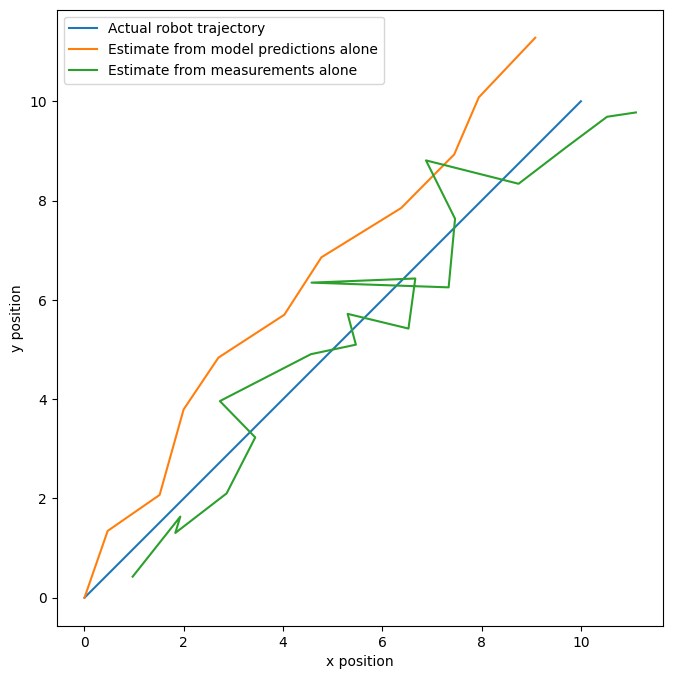

In [28]:
# état = [x_pos, y_pos]
num_data = 20
ground_truth_x = np.linspace(0, 10, num=num_data + 1)
ground_truth_y = ground_truth_x.copy() # x = y
delta_t = 1

# Simuler la dynamique
x_0, y_0 = 0, 0
xs, ys = [0], [0]
dynamics_noise_x_var = 0.3
dynamics_noise_y_var = 0.3
for _ in range(10):
    v_x, v_y = 1.0, 1.0
    noise_x = np.random.normal(loc=0.0, scale=dynamics_noise_x_var)
    noise_y = np.random.normal(loc=0.0, scale=dynamics_noise_y_var)
    new_x = xs[-1] + v_x * delta_t + noise_x
    new_y = ys[-1] + v_y * delta_t + noise_y
    xs.append(new_x)
    ys.append(new_y)
    
# Simuler les mesures
measurement_noise_x_var = 0.75
measurement_noise_y_var = 0.6
noise_x = np.random.normal(loc=0.0, scale=measurement_noise_x_var, size=num_data-1)
noise_y = np.random.normal(loc=0.0, scale=measurement_noise_y_var, size=num_data-1)
measurement_x = np.linspace(1, 10, num=num_data-1) + noise_x
measurement_y = np.linspace(1, 10, num=num_data-1) + noise_y

# Comparer les données de terrain et les mesures
plt.figure(figsize=(8,8))
plt.plot(ground_truth_x, ground_truth_y)
plt.plot(xs, ys)
plt.plot(measurement_x, measurement_y)
plt.xlabel('x position')
plt.ylabel('y position')
plt.legend(['Actual robot trajectory', 'Estimate from model predictions alone', 'Estimate from measurements alone'])
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Le graphique ci-dessus illustre la trajectoire réelle du robot, ainsi que l'estimation issue des mesures et celle obtenue par intégration directe du modèle de processus (également appelée navigation à l'estime "dead reckoning"). L'objectif du filtre de Kalman est d'améliorer l'estimation en combinant l'estimation de la dynamique et les mesures.

### Étape de prédiction

Rappelons l'étape de prédiction (i.e., obtenir $\bar{bel}(\mathbf{x}_{t}) = \mathcal{N}(\bar{\mu}_{t}, \bar{\Sigma}_{t}) $):
1. $\bar{\mu}_{t} = A\mu_{t-1} + Bu_{t}$
2. $\bar{\Sigma}_{t} = A\Sigma_{t-1}A^T + Q$

In [30]:
# Pour multiplier des matrices et des vecteurs, vous pouvez utiliser l'opérateur `@`.
def predict(A, B, Q, mu_t, u_t, Sigma_t):
    predicted_mu = mu_t  # TODO 
    predicted_Sigma = Sigma_t # TODO 
    return predicted_mu, predicted_Sigma

### Étape de correction

Rappel de l'étape de mise à jour :

1. Acquisition de la mesure $\mathbf{z}_{t}$
2. Calcul de la moyenne et de la covariance du résidu de prédiction : $\delta_{\mu} = \mathbf{z}_{t} - H\bar{\mu}_{t}$ et $\delta_{\Sigma} = H \bar{\Sigma}_{t} H^T + R$
3. Calcul du gain de Kalman : $K_{t} = \bar{\Sigma}_{t} H^T \delta_{\Sigma}^{-1}$
4. Calcul de la moyenne et de la covariance de la croyance : $\mu_{t} = \bar{\mu}_{t} + K\delta_{\mu}$ et $\Sigma_{t} = \bar{\Sigma}_{t} - KH\bar{\Sigma}_{t}$

In [33]:
def update(H, R, z, predicted_mu, predicted_Sigma):
    updated_mu = predicted_mu # TODO 
    updated_Sigma = predicted_Sigma # TODO 
    return updated_mu, updated_Sigma

Lançons notre filtre de Kalman !

In [34]:
# Initialiser le problème
mu_0 = np.array([0, 0])
Sigma_0 = np.array([[0.1, 0],
                     [0, 0.1]]) 
A = np.array([[1, 0],
              [0, 1]])
B = np.array([[1, 0],
              [0, 1]])
Q = np.array([[dynamics_noise_x_var, 0],
              [0, dynamics_noise_x_var]])
H = np.array([[1, 0],
              [0, 1]])
R = np.array([[measurement_noise_x_var, 0],
              [0, measurement_noise_y_var]])

# Initialiser des listes vides pour les µs et les mesures à tracer.
measurements = []
filtered_mus = []

# Exécuter KF pour chaque pas de temps
mu_current = mu_0.copy()
Sigma_current = Sigma_0.copy()
for i in range(num_data-1):
    u_t = np.array([1, 1])
    
    # prédiction
    predicted_mu, predicted_Sigma = predict(A, B, Q, 
                                            mu_current, u_t, 
                                            Sigma_current)
    
    # obtenir la mésure
    measurement_noise_x = np.random.normal(loc=0.0, scale=measurement_noise_x_var)
    measurement_noise_y = np.random.normal(loc=0.0, scale=measurement_noise_y_var)
    measurement_x_new = ground_truth_x[i+1] + measurement_noise_x
    measurement_y_new = ground_truth_x[i+1] + measurement_noise_y
    z = np.array([measurement_x_new, measurement_y_new])
    
    # correction
    mu_current, Sigma_current = update(H, R, z, 
                                   predicted_mu, 
                                   predicted_Sigma)
    
    # Stockez les mesures et le courant mu pour pouvoir les représenter graphiquement ultérieurement.
    measurements.append([measurement_x_new, measurement_y_new])
    filtered_mus.append(mu_current)

# Uniquement à des fins de visualisation, convertissez les listes en arrays. 
measurements = np.array(measurements)
filtered_mus = np.array(filtered_mus) 

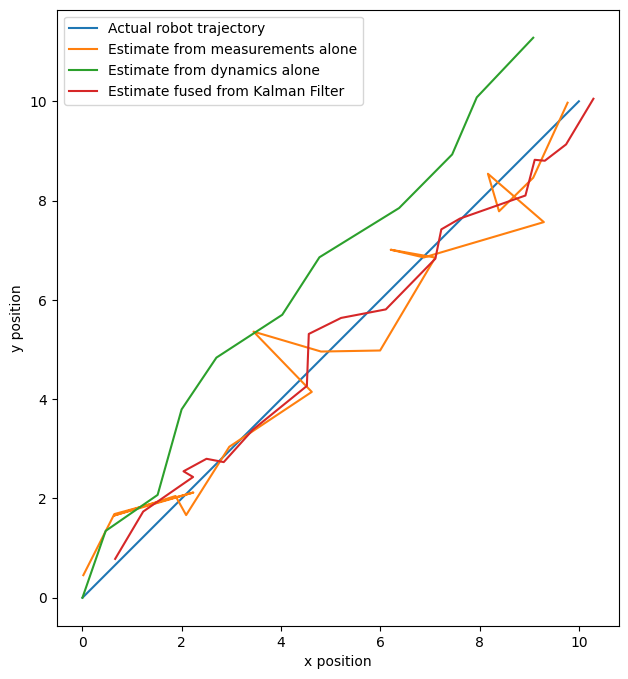

In [40]:
# Représentons graphiquement les résultats

plt.figure(figsize=(8,8))
plt.plot(ground_truth_x, ground_truth_y)
plt.plot(measurements[:,0], measurements[:,1])
plt.plot(xs, ys)
plt.plot(filtered_mus[:,0], filtered_mus[:,1])
plt.xlabel('x position')
plt.ylabel('y position')
plt.legend(['Actual robot trajectory', 'Estimate from measurements alone', 'Estimate from dynamics alone', 'Estimate fused from Kalman Filter'])
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Vous devriez constater que le filtre de Kalman est capable de fusionner toutes les informations et de nous fournir une meilleure estimation finale de la trajectoire du robot.

Passons maintenant au prochain notebook concernant les [filtres particulaires](../02-particle-filter/particle-filter.ipynb)